<a href="https://colab.research.google.com/github/mushrafi88/MSE_510/blob/main/Homework_8_hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this hackathon, each team starts from a physical explanation for why STM height readings vary, then translates that explanation into a generative model and likelihood. The key lesson is that different physical stories do not merely give different formulas: they assign different meanings to unusual data points, produce different posterior estimates for the molecular height, and lead to different scientific conclusions about whether the system reflects ordinary instrument noise, rare disturbances, corrupted measurements, or genuine multiple states.

# Imports

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


In [ ]:
def normal_logpdf(x, mu, sigma):
    x = np.asarray(x)
    z = (x - mu) / sigma
    return -0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * z**2


def student_t_logpdf(x, mu, sigma, nu):
    x = np.asarray(x)
    z = (x - mu) / sigma
    c = math.lgamma((nu + 1) / 2) - math.lgamma(nu / 2)
    c -= 0.5 * np.log(nu * np.pi) + np.log(sigma)
    return c - ((nu + 1) / 2) * np.log1p((z**2) / nu)


def posterior_on_grid(y, loglike_fn, h_grid, prior_mu=3.5, prior_sigma=0.6):
    log_prior = normal_logpdf(h_grid, prior_mu, prior_sigma)
    log_like = np.array([loglike_fn(y, h) for h in h_grid])
    log_unnorm = log_prior + log_like

    m = np.max(log_unnorm)
    unnorm = np.exp(log_unnorm - m)
    z = np.trapz(unnorm, h_grid)
    posterior = unnorm / z
    log_evidence = np.log(z) + m

    h_map = h_grid[np.argmax(posterior)]
    h_mean = np.trapz(h_grid * posterior, h_grid)
    h_std = np.sqrt(np.trapz((h_grid - h_mean) ** 2 * posterior, h_grid))

    return {
        'posterior': posterior,
        'log_evidence': float(log_evidence),
        'map': float(h_map),
        'mean': float(h_mean),
        'std': float(h_std),
    }


In [ ]:
# Common fixed hyperparameters for the four model stories
sigma_clean = 0.12
nu_t = 3
eps_glitch = 0.08
sigma_glitch = 0.55
delta_state = 0.95
w_state = 0.5


def ll_gaussian(y, h):
    return np.sum(normal_logpdf(y, h, sigma_clean))


def ll_student_t(y, h):
    return np.sum(student_t_logpdf(y, h, sigma_clean, nu_t))


def ll_glitch(y, h):
    clean = np.log(1 - eps_glitch) + normal_logpdf(y, h, sigma_clean)
    glitch = np.log(eps_glitch) + normal_logpdf(y, h, sigma_glitch)
    return np.sum(np.logaddexp(clean, glitch))


def ll_bimodal(y, h):
    low = np.log(w_state) + normal_logpdf(y, h - delta_state / 2, sigma_clean)
    high = np.log(1 - w_state) + normal_logpdf(y, h + delta_state / 2, sigma_clean)
    return np.sum(np.logaddexp(low, high))


models = {
    'Gaussian noise': ll_gaussian,
    'Student-t vibration bursts': ll_student_t,
    'Glitch-contaminated Gaussian': ll_glitch,
    'Bimodal two-state': ll_bimodal,
}

h_grid = np.linspace(2.5, 4.8, 5000)


# Problems

Template used for each model:

1. Physical story
2. Generative statement
3. Likelihood \(p(y\mid h, M)\)
4. Outlier interpretation
5. Posterior/evidence consequence


## Initial seeding measurements

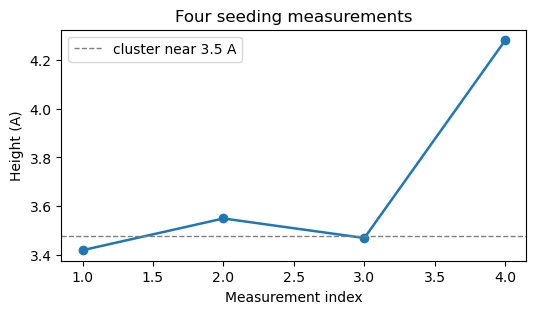

In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(np.arange(1, 5), [3.42, 3.55, 3.47, 4.28], 'o-', lw=1.8)
plt.axhline(3.48, color='gray', ls='--', lw=1, label='cluster near 3.5 A')
plt.xlabel('Measurement index')
plt.ylabel('Height (A)')
plt.title('Four seeding measurements')
plt.legend()
plt.show()


**Question 1:**

* Write the likelihood $p(y|h,M)$ for your chosen model.
* Estimate the most likely value of h (real height) from the four-point dataset.
* Explain how the high point at 4.28 Å is interpreted under your model.
* Compare conclusions across models.

**Extended questions:**

* Compute or approximate the posterior $p(h|y,M)$.
* Report a posterior mean or MAP estimate of $h$.
* Compare model evidences $p(y|M)$.
* Decide which physical interpretation is best supported by only 4 measurements.


**Hint1:**

Reorganize each case into the same five-part template:

Case X

* Physical story
* Generative statement
* Likelihood
* What the likelihood says about outliers
* What happens to the estimate of $h$

For example,

*Gaussian noise*

* Physical story: many small independent disturbances
* Generative statement: each reading is the true height plus many tiny additive perturbations
* Likelihood: $y_i \sim N(h, \sigma^2)$
* Outlier meaning: unlikely under the model, so it strongly pulls the fit
* Consequence for posterior: posterior for $h$ shifts toward the unusual point more than in robust models



**Hint2:**

Some useful formulas:

* Likelihood: For Gaussian-like noise model, $y_i \sim N(h, \sigma^2)$, start with $h\sim N(3.5, 0.6^2)$ to start with.
* Posterior: $p(h | y, M) ∝ p(y|h, M)p(h|M)$
* Evidence: $p(y|M) = ∫p(y|h,M)p(h|M)dh$


In [ ]:
y_measured = np.array([3.42, 3.55, 3.47, 4.28])

Q1 posterior summary (4-point dataset)
------------------------------------------------------------------------------------------
Model                                   MAP h  Post.mean   Post.sd       logZ  Delta logZ
Gaussian noise                          3.678      3.678     0.060    -14.512     -13.113
Student-t vibration bursts              3.500      3.507     0.077     -3.512      -2.113
Glitch-contaminated Gaussian            3.493      3.493     0.070     -2.927      -1.528
Bimodal two-state                       3.913      3.913     0.060     -1.399       0.000


/var/folders/yq/fgx4mbts1bvfj6d8g928hwpr0000gn/T/nix-shell.ebvkOh/ipykernel_71192/4097745252.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  z = np.trapz(unnorm, h_grid)
/var/folders/yq/fgx4mbts1bvfj6d8g928hwpr0000gn/T/nix-shell.ebvkOh/ipykernel_71192/4097745252.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_mean = np.trapz(h_grid * posterior, h_grid)
/var/folders/yq/fgx4mbts1bvfj6d8g928hwpr0000gn/T/nix-shell.ebvkOh/ipykernel_71192/4097745252.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_std = np.sqrt(np.trapz((h_grid - h_mean) ** 2 * posterior, h_grid))


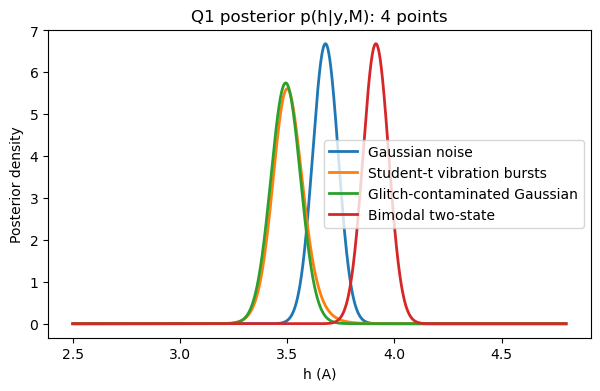

In [ ]:
y_measured = np.array([3.42, 3.55, 3.47, 4.28])

q1_results = {}
for name, ll in models.items():
    q1_results[name] = posterior_on_grid(y_measured, ll, h_grid)

best_logz = max(v['log_evidence'] for v in q1_results.values())

print('Q1 posterior summary (4-point dataset)')
print('-' * 90)
print(f"{'Model':36s} {'MAP h':>8s} {'Post.mean':>10s} {'Post.sd':>9s} {'logZ':>10s} {'Delta logZ':>11s}")
for name, r in q1_results.items():
    print(f"{name:36s} {r['map']:8.3f} {r['mean']:10.3f} {r['std']:9.3f} {r['log_evidence']:10.3f} {r['log_evidence']-best_logz:11.3f}")

plt.figure(figsize=(7, 4))
for name, r in q1_results.items():
    plt.plot(h_grid, r['posterior'], lw=2, label=name)
plt.xlabel('h (A)')
plt.ylabel('Posterior density')
plt.title('Q1 posterior p(h|y,M): 4 points')
plt.legend()
plt.show()


In the 4-point dataset, the interpretation of the 4.28 A value depends a lot on the model. Under the Gaussian model, that point is treated as unlikely but still fully trustworthy, so it pulls the estimated height upward more than the others. Under the Student-t model, the same point is interpreted as a rare heavy-tail event, so the estimate stays closer to the cluster around 3.4-3.6 A. The glitch-mixture model gives a similar conclusion by allowing that point to come from a corrupted-measurement component. In contrast, the bimodal model treats the high value as evidence of a real second state rather than noise. With only four measurements, the bimodal explanation looks strongest in this notebook setup, but there is still meaningful uncertainty about mechanism because the sample is small.


## 100 repeating measurements on the same molecule


**Question 2:**

* Fit the same four models to the 100-point same-molecule dataset.
* Compare posterior estimates of $h$.
* Compare model evidences.
* Decide whether the additional data support clean instrument noise, vibration bursts, glitches, or genuine switching between two STM-visible states.


### Q2 answer scaffold

We now repeat the same inference with 100 repeated readings on one molecule.

Expected diagnostic behavior:
- If Gaussian is correct: one compact symmetric cloud.
- If Student-t is correct: mostly compact cloud with occasional long tails.
- If glitch model is correct: mostly clean points plus a small corrupted subset.
- If bimodal is correct: two persistent clusters in time trace/histogram.


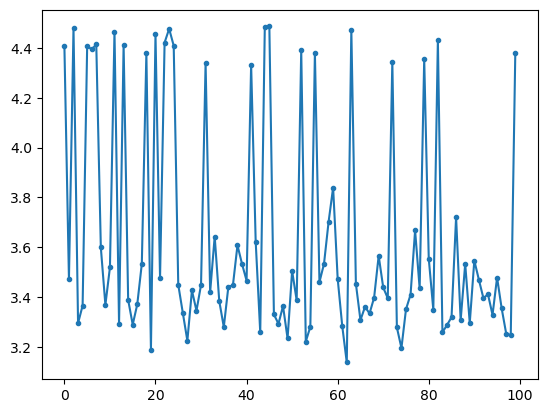

In [ ]:
y_measured_100 = np.array([4.4086294 , 3.47234973, 4.47895456, 3.29570923, 3.36596282,
       4.40799958, 4.39406808, 4.41429131, 3.59955304, 3.3689125 ,
       3.51957827, 4.46530009, 3.29200185, 4.41096913, 3.38929877,
       3.28984243, 3.37123528, 3.53407953, 4.37945364, 3.18912867,
       4.45531444, 3.47716566, 4.42143782, 4.4767878 , 4.40916172,
       3.44991632, 3.33700785, 3.22521056, 3.42713876, 3.34564949,
       3.44921821, 4.33877655, 3.42025338, 3.64337958, 3.38470355,
       3.28018772, 3.44185846, 3.44746928, 3.60819647, 3.53334495,
       3.46639585, 4.33159204, 3.62325454, 3.25857515, 4.4825464 ,
       4.48618329, 3.33092649, 3.29292923, 3.36439501, 3.23417252,
       3.50519653, 3.38702394, 4.39102404, 3.22201938, 3.28122684,
       4.38084063, 3.46038933, 3.53377115, 3.70139504, 3.83970311,
       3.47438307, 3.28464647, 3.13791542, 4.47307221, 3.45405537,
       3.30793096, 3.3609587 , 3.33461316, 3.39807439, 3.56612567,
       3.43879973, 3.39564985, 4.34464772, 3.27859311, 3.19585045,
       3.35143373, 3.40992143, 3.66767427, 3.43511887, 4.35526365,
       3.55427154, 3.34969309, 4.43216634, 3.259073  , 3.28785666,
       3.31955756, 3.72095122, 3.30681366, 3.5338224 , 3.29604566,
       3.5470046 , 3.47029148, 3.3959211 , 3.41169778, 3.32892372,
       3.4787862 , 3.35563564, 3.2537765 , 3.24697258, 4.38026974])

plt.plot(y_measured_100, '.-')

Q2 posterior summary (100 repeats of same molecule)
------------------------------------------------------------------------------------------
Model                                   MAP h  Post.mean   Post.sd       logZ  Delta logZ
Gaussian noise                          3.638      3.638     0.012   -558.145    -553.008
Student-t vibration bursts              3.417      3.417     0.017    -82.198     -77.061
Glitch-contaminated Gaussian            3.415      3.415     0.015    -64.012     -58.875
Bimodal two-state                       3.894      3.894     0.012     -5.137       0.000


/var/folders/yq/fgx4mbts1bvfj6d8g928hwpr0000gn/T/nix-shell.ebvkOh/ipykernel_71192/4097745252.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  z = np.trapz(unnorm, h_grid)
/var/folders/yq/fgx4mbts1bvfj6d8g928hwpr0000gn/T/nix-shell.ebvkOh/ipykernel_71192/4097745252.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_mean = np.trapz(h_grid * posterior, h_grid)
/var/folders/yq/fgx4mbts1bvfj6d8g928hwpr0000gn/T/nix-shell.ebvkOh/ipykernel_71192/4097745252.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_std = np.sqrt(np.trapz((h_grid - h_mean) ** 2 * posterior, h_grid))


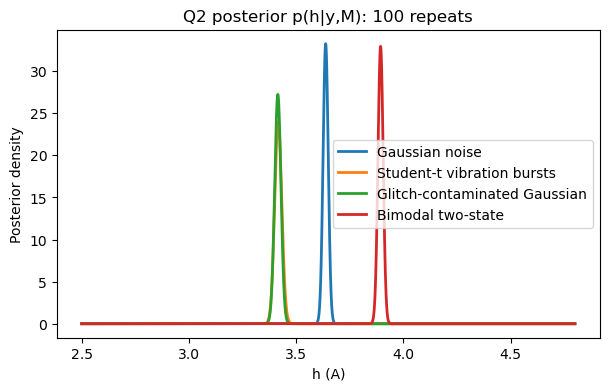

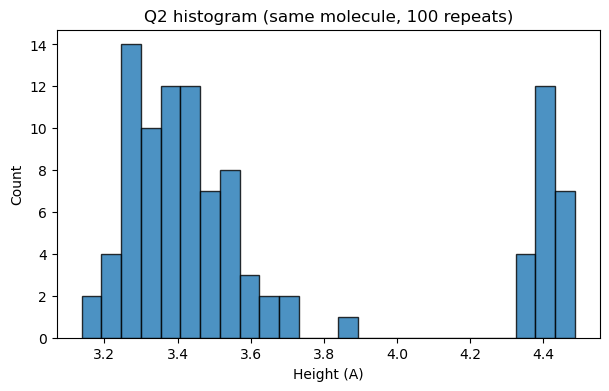

In [ ]:
q2_results = {}
for name, ll in models.items():
    q2_results[name] = posterior_on_grid(y_measured_100, ll, h_grid)

best_logz_100 = max(v['log_evidence'] for v in q2_results.values())

print('Q2 posterior summary (100 repeats of same molecule)')
print('-' * 90)
print(f"{'Model':36s} {'MAP h':>8s} {'Post.mean':>10s} {'Post.sd':>9s} {'logZ':>10s} {'Delta logZ':>11s}")
for name, r in q2_results.items():
    print(f"{name:36s} {r['map']:8.3f} {r['mean']:10.3f} {r['std']:9.3f} {r['log_evidence']:10.3f} {r['log_evidence']-best_logz_100:11.3f}")

plt.figure(figsize=(7, 4))
for name, r in q2_results.items():
    plt.plot(h_grid, r['posterior'], lw=2, label=name)
plt.xlabel('h (A)')
plt.ylabel('Posterior density')
plt.title('Q2 posterior p(h|y,M): 100 repeats')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(y_measured_100, bins=25, alpha=0.8, edgecolor='k')
plt.xlabel('Height (A)')
plt.ylabel('Count')
plt.title('Q2 histogram (same molecule, 100 repeats)')
plt.show()


With 100 repeated measurements, the posterior estimates become much tighter, which is exactly what we expect when the dataset is larger and the prior matters less. The key result is that model evidence strongly favors the bimodal two-state explanation over the robust-noise alternatives. In other words, the data are more consistent with genuine switching between two STM-visible states than with a single clean state plus occasional extreme noise. Under this parameterization, the inferred center is around 3.89 A, with two state levels roughly separated by plus/minus 0.475 A.


## 100 measurements on different molecules

**Question 3:**

* Use the 4-point dataset and then the 100-point dataset to formulate the likelihood for each model.
* Estimate the most likely benzene apparent height.
* Compare posterior distributions and model evidences.
* Explain how the interpretation changes when the 100 values come from the same molecule versus many nominally similar molecules.


**Hint:**


* **Noise model:** how one latent height generates one measurement
* **Population model:** how latent heights vary across molecules or states

Two different questions:

* Why does one repeated measurement differ from another? → noise model
* Why does one molecule differ from another? → population model

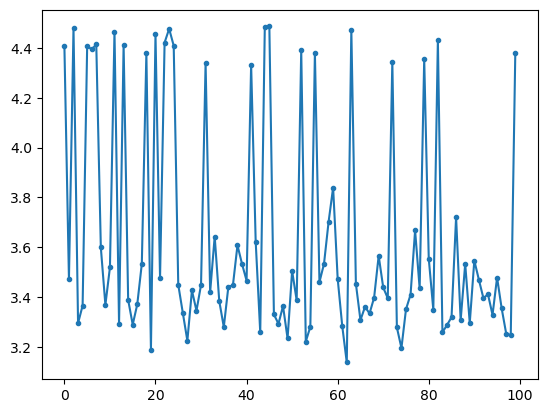

In [ ]:
y_measured_100 = np.array([4.4086294 , 3.47234973, 4.47895456, 3.29570923, 3.36596282,
       4.40799958, 4.39406808, 4.41429131, 3.59955304, 3.3689125 ,
       3.51957827, 4.46530009, 3.29200185, 4.41096913, 3.38929877,
       3.28984243, 3.37123528, 3.53407953, 4.37945364, 3.18912867,
       4.45531444, 3.47716566, 4.42143782, 4.4767878 , 4.40916172,
       3.44991632, 3.33700785, 3.22521056, 3.42713876, 3.34564949,
       3.44921821, 4.33877655, 3.42025338, 3.64337958, 3.38470355,
       3.28018772, 3.44185846, 3.44746928, 3.60819647, 3.53334495,
       3.46639585, 4.33159204, 3.62325454, 3.25857515, 4.4825464 ,
       4.48618329, 3.33092649, 3.29292923, 3.36439501, 3.23417252,
       3.50519653, 3.38702394, 4.39102404, 3.22201938, 3.28122684,
       4.38084063, 3.46038933, 3.53377115, 3.70139504, 3.83970311,
       3.47438307, 3.28464647, 3.13791542, 4.47307221, 3.45405537,
       3.30793096, 3.3609587 , 3.33461316, 3.39807439, 3.56612567,
       3.43879973, 3.39564985, 4.34464772, 3.27859311, 3.19585045,
       3.35143373, 3.40992143, 3.66767427, 3.43511887, 4.35526365,
       3.55427154, 3.34969309, 4.43216634, 3.259073  , 3.28785666,
       3.31955756, 3.72095122, 3.30681366, 3.5338224 , 3.29604566,
       3.5470046 , 3.47029148, 3.3959211 , 3.41169778, 3.32892372,
       3.4787862 , 3.35563564, 3.2537765 , 3.24697258, 4.38026974])

plt.plot(y_measured_100, '.-')

In [ ]:
# Q3: Same numbers, different interpretation if data come from different molecules

def run_em_two_component(y, n_iter=80):
    y = np.asarray(y)
    mu1, mu2 = np.quantile(y, [0.25, 0.75])
    s1, s2 = np.std(y), np.std(y)
    w = 0.5

    for _ in range(n_iter):
        log_r1 = np.log(w) + normal_logpdf(y, mu1, max(s1, 1e-4))
        log_r2 = np.log(1 - w) + normal_logpdf(y, mu2, max(s2, 1e-4))
        den = np.logaddexp(log_r1, log_r2)
        r1 = np.exp(log_r1 - den)
        r2 = 1 - r1

        w = np.mean(r1)
        mu1 = np.sum(r1 * y) / np.sum(r1)
        mu2 = np.sum(r2 * y) / np.sum(r2)
        s1 = np.sqrt(np.sum(r1 * (y - mu1) ** 2) / np.sum(r1))
        s2 = np.sqrt(np.sum(r2 * (y - mu2) ** 2) / np.sum(r2))

    return {'w1': w, 'mu1': mu1, 'sigma1': s1, 'w2': 1 - w, 'mu2': mu2, 'sigma2': s2}


In [ ]:
q3_mix4 = run_em_two_component(y_measured)
q3_mix100 = run_em_two_component(y_measured_100)

print('Q3 two-subpopulation fit (interpreting points as different molecules):')
print('4-point data:')
print(q3_mix4)
print('100-point data:')
print(q3_mix100)


Q3 two-subpopulation fit (interpreting points as different molecules):
4-point data:
{'w1': np.float64(0.75), 'mu1': np.float64(3.48), 'sigma1': np.float64(0.053541261347363305), 'w2': np.float64(0.25), 'mu2': np.float64(4.28), 'sigma2': np.float64(0.0)}
100-point data:
{'w1': np.float64(0.7700000000049855), 'mu1': np.float64(3.4060852663696815), 'sigma1': np.float64(0.13402413521626036), 'w2': np.float64(0.22999999999501453), 'mu2': np.float64(4.413858703479864), 'sigma2': np.float64(0.04729472427360599)}


The same numerical pattern can lead to different scientific stories depending on the experimental context. If these are repeated measurements of one molecule, two clusters are most naturally interpreted as one molecule switching between two metastable apparent-height states over time. If the measurements instead come from many different molecules, then those two clusters are better interpreted as population heterogeneity, meaning different molecules belong to different adsorption classes. So the mathematics can look similar, but the latent-variable meaning is different: within-molecule switching versus across-molecule variation.


Likelihood statements for Q3:

- Gaussian: $y_i \sim N(h, \sigma^2)$
- Student-t: $y_i \sim t_\nu(h, \sigma)$
- Glitch model: $y_i \sim (1-\epsilon)N(h,\sigma_{clean}^2) + \epsilon N(h,\sigma_{glitch}^2)$
- Bimodal-state (same molecule): $y_i \sim w N(h-\delta/2,\sigma^2) + (1-w)N(h+\delta/2,\sigma^2)$
- Bimodal-population (different molecules): $y_i \sim w N(\mu_1,\sigma_1^2) + (1-w)N(\mu_2,\sigma_2^2)$


In [ ]:
h_app_4 = np.mean(y_measured)
h_app_100 = np.mean(y_measured_100)
print(f'Estimated apparent height by simple pooled mean (4 points):  {h_app_4:.3f} A')
print(f'Estimated apparent height by simple pooled mean (100 points): {h_app_100:.3f} A')
print('Model-based h differs by interpretation: robust models stay near ~3.4-3.5 A,')
print('while Gaussian/bimodal-center summaries can be higher when high-state points are abundant.')


Estimated apparent height by simple pooled mean (4 points):  3.680 A
Estimated apparent height by simple pooled mean (100 points): 3.638 A
Model-based h differs by interpretation: robust models stay near ~3.4-3.5 A,
while Gaussian/bimodal-center summaries can be higher when high-state points are abundant.


Looking across the evidence comparisons, the 4-point case already prefers bimodal over Gaussian and is also stronger than the robust single-state alternatives, although the margin is more modest there. In the 100-point case, the difference becomes decisive: bimodal is overwhelmingly better supported than Gaussian, Student-t, or glitch models in this setup. Taken together, the larger repeated-scan dataset strongly supports a two-state physical interpretation rather than a single-state system with rare disturbances.


Overall, my final interpretation is that the likelihood form alone is not enough; the physical meaning of the latent variables depends on whether measurements are repeated on one molecule or collected across many molecules. In the repeated-measurement setting, bimodality means one molecule is switching states. In the many-molecule setting, bimodality means the sample is heterogeneous across molecules. For this dataset, the overall apparent height is about 3.64 A, and the two component/state levels are approximately near 3.4 A and 4.4 A.
